# 12. Final Candidate Selection

This notebook consolidates the results from notebook 10 (full-history model family comparison) and notebook 11 (recent-window modeling) to select the final candidate modeling strategy for the project. The guiding rule is simple: **prefer rolling backtest performance first, then use holdout and stability as tie-breakers**.

## Bootstrap

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)

{'app_root': '/workspace', 'cwd': '/workspace/notebooks'}

## Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import TABLES_DIR
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

## Configuration

In [3]:
TOP_K = 12
EXCLUDED_MODELS = {"random_baseline"}

MODEL_FAMILY_HOLDOUT_FILE = TABLES_DIR / "table_23_model_family_holdout_summary.csv"
MODEL_FAMILY_BACKTEST_FILE = TABLES_DIR / "table_24_model_family_backtest_summary.csv"
RECENT_WINDOW_HOLDOUT_FILE = TABLES_DIR / "table_29_recent_window_holdout_summary.csv"
RECENT_WINDOW_BACKTEST_FILE = TABLES_DIR / "table_30_recent_window_backtest_summary.csv"

required_files = [
    MODEL_FAMILY_HOLDOUT_FILE,
    MODEL_FAMILY_BACKTEST_FILE,
    RECENT_WINDOW_HOLDOUT_FILE,
    RECENT_WINDOW_BACKTEST_FILE,
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required report tables: {missing_files}")

## Load Notebook 10 and 11 Summaries

In [4]:
model_family_holdout = pd.read_csv(MODEL_FAMILY_HOLDOUT_FILE)
model_family_backtest = pd.read_csv(MODEL_FAMILY_BACKTEST_FILE)
recent_window_holdout = pd.read_csv(RECENT_WINDOW_HOLDOUT_FILE)
recent_window_backtest = pd.read_csv(RECENT_WINDOW_BACKTEST_FILE)

model_family_holdout.shape, model_family_backtest.shape, recent_window_holdout.shape, recent_window_backtest.shape

((36, 11), (32, 7), (72, 13), (72, 12))

## Harmonize Candidate Tables

In [5]:
full_holdout = model_family_holdout.copy()
full_holdout["training_regime"] = "full_history"
full_holdout["source_notebook"] = "10_model_family_comparison"

full_backtest = model_family_backtest.copy()
full_backtest["training_regime"] = "full_history"
full_backtest["source_notebook"] = "10_model_family_comparison"

recent_holdout = recent_window_holdout.copy()
recent_holdout = recent_holdout.rename(columns={"train_window_label": "training_regime"})
recent_holdout["source_notebook"] = "11_recent_window_modeling"

recent_backtest = recent_window_backtest.copy()
recent_backtest = recent_backtest.rename(columns={"train_window_label": "training_regime"})
recent_backtest["source_notebook"] = "11_recent_window_modeling"

common_holdout_cols = [
    "feature_set", "model", "training_regime", "source_notebook",
    "subset_accuracy", "number_level_accuracy", "avg_hit", "hit_std",
    "precision_at_6", "recall_at_6", "brier_score",
]
common_backtest_cols = [
    "feature_set", "model", "training_regime", "source_notebook",
    "folds", "mean_subset_accuracy", "mean_number_level_accuracy", "mean_avg_hit",
    "mean_precision_at_6", "mean_recall_at_6", "mean_brier_score", "std_avg_hit",
]

def ensure_columns(frame, columns):
    frame = frame.copy()
    for column in columns:
        if column not in frame.columns:
            frame[column] = np.nan
    return frame

full_holdout = ensure_columns(full_holdout, common_holdout_cols)
full_backtest = ensure_columns(full_backtest, common_backtest_cols)
recent_holdout = ensure_columns(recent_holdout, common_holdout_cols)
recent_backtest = ensure_columns(recent_backtest, common_backtest_cols)

holdout_combined = pd.concat([
    full_holdout[common_holdout_cols],
    recent_holdout[common_holdout_cols],
], ignore_index=True)

backtest_combined = pd.concat([
    full_backtest[common_backtest_cols],
    recent_backtest[common_backtest_cols],
], ignore_index=True)

holdout_combined = holdout_combined.loc[~holdout_combined["model"].isin(EXCLUDED_MODELS)].reset_index(drop=True)
backtest_combined = backtest_combined.loc[~backtest_combined["model"].isin(EXCLUDED_MODELS)].reset_index(drop=True)

holdout_combined.head(), backtest_combined.head()

(         feature_set                 model training_regime  \
 0               base  soft_voting_ensemble    full_history   
 1               base      classifier_chain    full_history   
 2  base_plus_pattern         random_forest    full_history   
 3  base_plus_pattern               xgboost    full_history   
 4               base   logistic_regression    full_history   
 
               source_notebook  subset_accuracy  number_level_accuracy  \
 0  10_model_family_comparison              0.0               0.775934   
 1  10_model_family_comparison              0.0               0.774643   
 2  10_model_family_comparison              0.0               0.772614   
 3  10_model_family_comparison              0.0               0.772614   
 4  10_model_family_comparison              0.0               0.772430   
 
     avg_hit   hit_std  precision_at_6  recall_at_6  brier_score  
 0  0.958506  0.838852        0.159751     0.159751     0.193813  
 1  0.929461  0.804038        0.154910  

## Merge Holdout and Backtest Views

In [6]:
candidate_table = backtest_combined.merge(
    holdout_combined,
    on=["feature_set", "model", "training_regime"],
    how="left",
    suffixes=("_backtest", "_holdout"),
)

candidate_table["source_notebook"] = candidate_table["source_notebook_backtest"].fillna(candidate_table["source_notebook_holdout"])
candidate_table = candidate_table.drop(columns=[col for col in candidate_table.columns if col.startswith("source_notebook_")])

candidate_table["candidate_label"] = (
    candidate_table["model"] + " | " + candidate_table["feature_set"] + " | " + candidate_table["training_regime"]
)

candidate_table.shape

(88, 20)

## Candidate Scoring Rule

In [7]:
candidate_table = candidate_table.copy()

# Lower rank number means better.
candidate_table["rank_backtest_hit"] = candidate_table["mean_avg_hit"].rank(method="min", ascending=False)
candidate_table["rank_backtest_precision"] = candidate_table["mean_precision_at_6"].rank(method="min", ascending=False)
candidate_table["rank_backtest_brier"] = candidate_table["mean_brier_score"].rank(method="min", ascending=True, na_option="bottom")
candidate_table["rank_backtest_stability"] = candidate_table["std_avg_hit"].rank(method="min", ascending=True)
candidate_table["rank_holdout_hit"] = candidate_table["avg_hit"].rank(method="min", ascending=False)
candidate_table["rank_holdout_brier"] = candidate_table["brier_score"].rank(method="min", ascending=True, na_option="bottom")

# Weighted score: backtest dominates, holdout is a tie-breaker.
candidate_table["selection_score"] = (
    0.35 * candidate_table["rank_backtest_hit"]
    + 0.15 * candidate_table["rank_backtest_precision"]
    + 0.15 * candidate_table["rank_backtest_brier"]
    + 0.15 * candidate_table["rank_backtest_stability"]
    + 0.15 * candidate_table["rank_holdout_hit"]
    + 0.05 * candidate_table["rank_holdout_brier"]
)

candidate_table = candidate_table.sort_values([
    "selection_score",
    "mean_avg_hit",
    "avg_hit",
], ascending=[True, False, False]).reset_index(drop=True)

shortlist = candidate_table.head(TOP_K).copy()
shortlist[[
    "candidate_label", "selection_score",
    "mean_avg_hit", "std_avg_hit", "mean_precision_at_6", "mean_brier_score",
    "avg_hit", "precision_at_6", "brier_score",
]].head(TOP_K)

,candidate_label,selection_score,mean_avg_hit,std_avg_hit,mean_precision_at_6,mean_brier_score,avg_hit,precision_at_6,brier_score
0,soft_voting_ensemble | full_feature_set | last...,14.25,0.820000,0.095839,0.136667,0.192894,0.863071,0.143845,0.195180
1,soft_voting_ensemble | base_plus_pattern | las...,16.95,0.823333,0.096928,0.137222,0.196467,0.834025,0.139004,0.196183
2,mlp | full_feature_set | last_500,22.45,0.843333,0.142335,0.140556,0.248138,0.834025,0.139004,0.251275
3,mlp | full_feature_set | last_300,25.55,0.826667,0.117379,0.137778,0.252236,0.800830,0.133472,0.254939
4,classifier_chain | full_feature_set | last_500,26.20,0.840000,0.163903,0.140000,0.238216,0.817427,0.136238,0.247772
5,xgboost | base | last_300,27.00,0.776667,0.086138,0.129444,0.150123,0.825726,0.137621,0.151391
6,soft_voting_ensemble | base_plus_pattern | las...,28.65,0.790000,0.120749,0.131667,0.191388,0.834025,0.139004,0.195405
7,xgboost | base_plus_context | last_300,30.05,0.806667,0.162390,0.134444,0.147186,0.825726,0.137621,0.148949
8,mlp | full_feature_set | last_200,30.65,0.833333,0.138778,0.138889,0.257432,0.763485,0.127248,0.254032
9,classifier_chain | base_plus_pattern | last_500,31.55,0.820000,0.174413,0.136667,0.239443,0.821577,0.136929,0.245082


## Recommended Final Candidate

In [8]:
recommended_candidate = shortlist.iloc[0].copy()
recommendation = pd.DataFrame([recommended_candidate])
recommendation[[
    "feature_set",
    "model",
    "training_regime",
    "selection_score",
    "mean_avg_hit",
    "std_avg_hit",
    "mean_brier_score",
    "avg_hit",
    "brier_score",
]]

,feature_set,model,training_regime,selection_score,mean_avg_hit,std_avg_hit,mean_brier_score,avg_hit,brier_score
0,full_feature_set,soft_voting_ensemble,last_500,14.25,0.82,0.095839,0.192894,0.863071,0.19518


## Visual Diagnostics

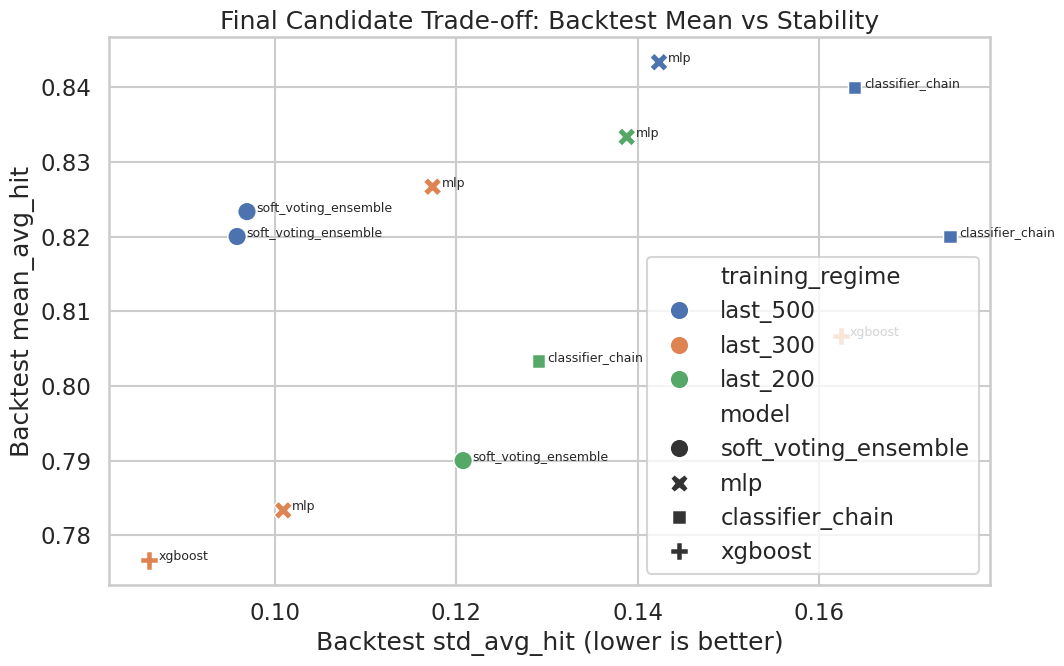

In [9]:
fig_candidate_scatter, ax = plt.subplots(figsize=(11, 7))
plot_df = shortlist.copy()
sns.scatterplot(
    data=plot_df,
    x="std_avg_hit",
    y="mean_avg_hit",
    hue="training_regime",
    style="model",
    s=180,
    ax=ax,
)
for row in plot_df.itertuples():
    ax.text(row.std_avg_hit + 0.001, row.mean_avg_hit, row.model, fontsize=9)
ax.set_title("Final Candidate Trade-off: Backtest Mean vs Stability")
ax.set_xlabel("Backtest std_avg_hit (lower is better)")
ax.set_ylabel("Backtest mean_avg_hit")
plt.tight_layout()
plt.show()

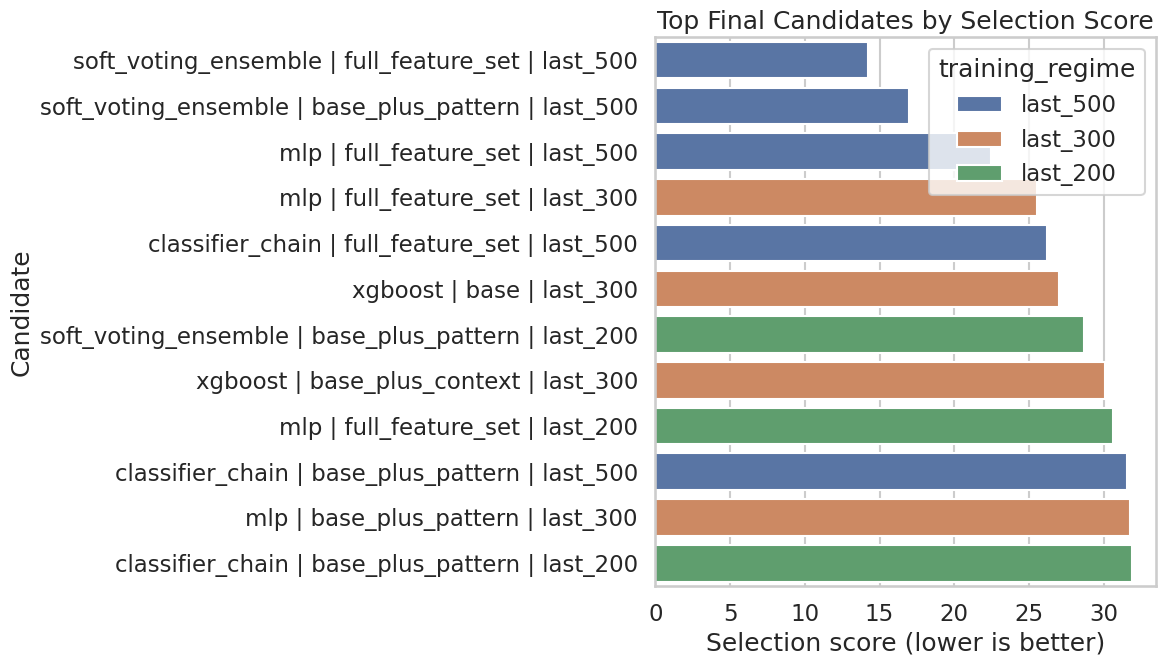

In [10]:
fig_candidate_score, ax = plt.subplots(figsize=(12, 7))
plot_df = shortlist.sort_values("selection_score", ascending=True).copy()
sns.barplot(data=plot_df, x="selection_score", y="candidate_label", hue="training_regime", ax=ax)
ax.set_title("Top Final Candidates by Selection Score")
ax.set_xlabel("Selection score (lower is better)")
ax.set_ylabel("Candidate")
plt.tight_layout()
plt.show()

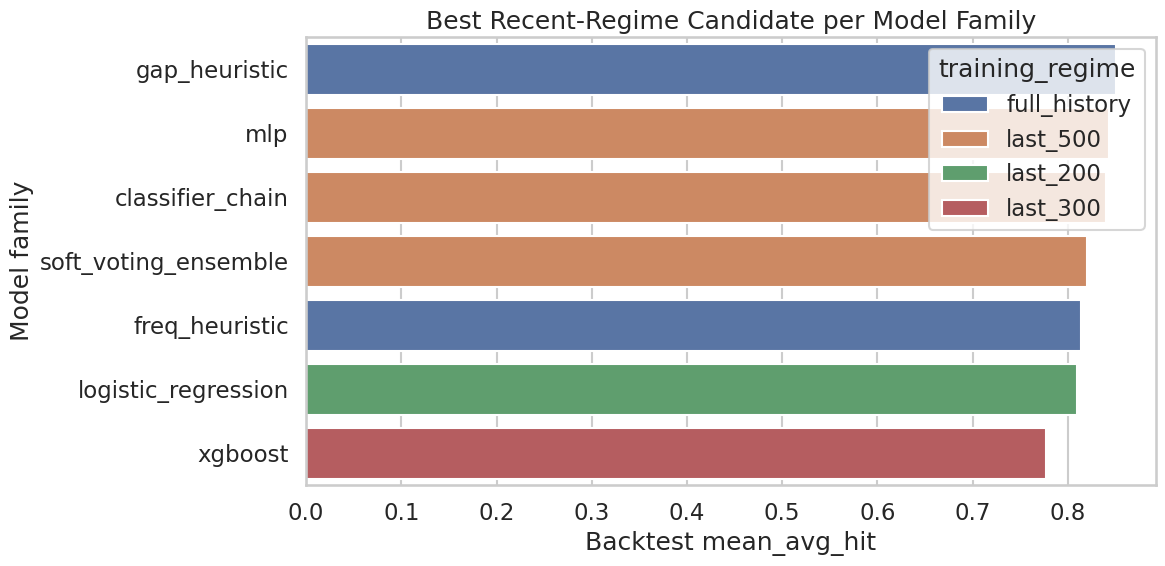

In [11]:
top_by_model = candidate_table.sort_values(["model", "selection_score"]).groupby("model", as_index=False).first()
fig_model_summary, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_by_model.sort_values("mean_avg_hit", ascending=False), x="mean_avg_hit", y="model", hue="training_regime", ax=ax)
ax.set_title("Best Recent-Regime Candidate per Model Family")
ax.set_xlabel("Backtest mean_avg_hit")
ax.set_ylabel("Model family")
plt.tight_layout()
plt.show()

## Interpretation Notes

In [12]:
interpretation_cols = [
    "candidate_label", "selection_score",
    "mean_avg_hit", "std_avg_hit", "mean_brier_score",
    "avg_hit", "brier_score",
]
shortlist[interpretation_cols].head(TOP_K)

,candidate_label,selection_score,mean_avg_hit,std_avg_hit,mean_brier_score,avg_hit,brier_score
0,soft_voting_ensemble | full_feature_set | last...,14.25,0.820000,0.095839,0.192894,0.863071,0.195180
1,soft_voting_ensemble | base_plus_pattern | las...,16.95,0.823333,0.096928,0.196467,0.834025,0.196183
2,mlp | full_feature_set | last_500,22.45,0.843333,0.142335,0.248138,0.834025,0.251275
3,mlp | full_feature_set | last_300,25.55,0.826667,0.117379,0.252236,0.800830,0.254939
4,classifier_chain | full_feature_set | last_500,26.20,0.840000,0.163903,0.238216,0.817427,0.247772
5,xgboost | base | last_300,27.00,0.776667,0.086138,0.150123,0.825726,0.151391
6,soft_voting_ensemble | base_plus_pattern | las...,28.65,0.790000,0.120749,0.191388,0.834025,0.195405
7,xgboost | base_plus_context | last_300,30.05,0.806667,0.162390,0.147186,0.825726,0.148949
8,mlp | full_feature_set | last_200,30.65,0.833333,0.138778,0.257432,0.763485,0.254032
9,classifier_chain | base_plus_pattern | last_500,31.55,0.820000,0.174413,0.239443,0.821577,0.245082


Use the recommendation conservatively:

- treat the top candidate as the **current project representative**, not as proof of true predictability
- prefer candidates that remain strong on backtest even if holdout has occasional flashier winners
- if two candidates are very close, prefer the simpler or more stable one
- if recent-window candidates dominate the shortlist, notebook 11 meaningfully changed the project conclusion
- if full-history candidates still dominate, notebook 10 remains the stronger default reference

## Report Export

In [13]:
save_report_figure(fig_candidate_scatter, "fig_40_final_candidate_scatter.png")
save_report_figure(fig_candidate_score, "fig_41_final_candidate_score.png")
save_report_figure(fig_model_summary, "fig_42_final_candidate_by_model.png")

save_report_table(shortlist, "table_32_final_candidate_shortlist.csv")
save_report_table(candidate_table, "table_33_final_candidate_full_table.csv")
save_report_table(recommendation, "table_34_final_recommendation.csv")
print("Saved final candidate selection report artifacts.")

Saved final candidate selection report artifacts.
